# Sensitivity Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
from globals import main_dir,data_dir

from Rotor import Rotor

#### Default rotor configuration

In [2]:
j = 1.2
R = 0.7
Vinf = np.array([60,0,0])
n = Vinf[0]/(j*2*R)
Ome  = n*2*np.pi
Vinf = np.array([60,0,0])
Vinf_wing = np.array([1,0,0])
c_R_func:Callable = lambda r_R : 0.18-0.06*r_R
twst_func:Callable = lambda r_R : -50*r_R+35
wing_c_R_func:Callable = lambda r_R: np.ones(shape=r_R.shape)/10 #=1
wing_twst_func:Callable = lambda r_R : r_R*0

In [ ]:
n_elems_per_period_lst = np.arange(1,20,1,dtype = int)
perf_lst = []
for n_elems_per_period in n_elems_per_period_lst:
    rotor = Rotor(B=6,
                    R=R,
                    r_R_H=0.25,
                    c_R_func=c_R_func,
                    twst_func=twst_func,
                    pitch=45,
                    polar_path=data_dir.joinpath("ARAD8pct_polar.txt"),
                    Omega = Ome,
                    Vinf=Vinf,
                    rho=1.067,
                    n_elem=10,
                    dist_elem="uniform",
                    periods = 1,
                    n_elems_per_wake=n_elems_per_period
                    )
    rotor.solve()
    perf_dict = rotor.calculate_spanwise_performance()
    perf_lst.append(perf_dict)

Converged in 37 iterations
Converged in 36 iterations
Converged in 37 iterations
Converged in 38 iterations
Converged in 38 iterations
Converged in 39 iterations
Converged in 39 iterations
Converged in 39 iterations
Converged in 39 iterations
Converged in 39 iterations
Converged in 39 iterations
Converged in 39 iterations
Converged in 39 iterations
Converged in 39 iterations
Converged in 39 iterations
Converged in 39 iterations
Converged in 39 iterations
Converged in 39 iterations
Converged in 39 iterations


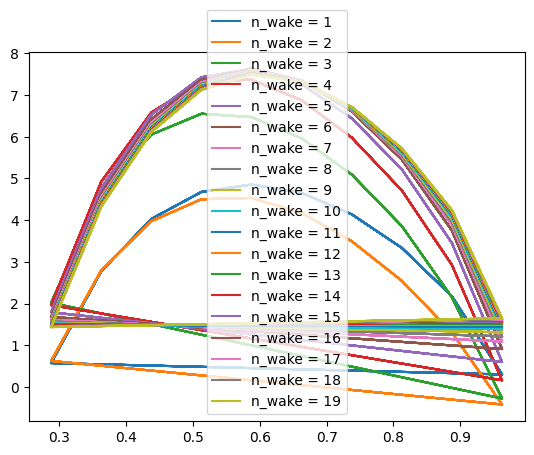

In [ ]:
for i in range(len(perf_lst)):
    plt.plot(perf_lst[i]["r_R"],perf_lst[i]["alpha"],label=f"n_wake = {i+1}")
plt.legend()